In [12]:
import speech_recognition as sr
import pyttsx3
import smtplib
import imaplib
import email
import time
from email.mime.text import MIMEText
from email.header import decode_header


import json
import datetime

# -------- PIN SECURITY --------
USER_PIN = "1234"

def verify_pin():
    speak("Please say your PIN")
    pin = listen()

    if pin == USER_PIN:
        speak("PIN verified")
        return True
    else:
        speak("Wrong PIN")
        return False

# -------- LOGGING --------
def log_activity(action):
    data = {
        "action": action,
        "time": str(datetime.datetime.now())
    }

    try:
        with open("logs.json", "r") as f:
            logs = json.load(f)
    except:
        logs = []

    logs.append(data)

    with open("logs.json", "w") as f:
        json.dump(logs, f, indent=4)

#TEXT TO SPEECH
def speak(text):
    print("Assistant:", text)

    engine = pyttsx3.init('sapi5')
    engine.setProperty('rate', 170)
    engine.setProperty('volume', 1.0)

    engine.say(text)
    engine.runAndWait()
    engine.stop()

    time.sleep(1)

#SPEECH TO TEXT
def listen():
    r = sr.Recognizer()
    with sr.Microphone() as source:
        print("Listening...")
        audio = r.listen(source)

    try:
        text = r.recognize_google(audio)
        print("You:", text)
        return text.lower()
    except:
        speak("Sorry, I didn't understand.")
        return ""

#EMAIL LOGIN
def login_email():
    speak("Enter your Gmail ID")
    email_id = input("Email: ")

    speak("Enter your Gmail App Password")
    password = input("App Password: ")

    try:
        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        server.login(email_id, password)
        speak("Login successful")
        return server, email_id, password
    except Exception as e:
        print(e)
        speak("Login failed")
        return None, None, None

#SEND EMAIL
def send_email(sender, password):
    if not verify_pin():
        log_activity("Unauthorized Send Attempt")
        return
        
    speak("Say receiver email address")
    receiver = listen()

    receiver = receiver.replace(" at ", "@")
    receiver = receiver.replace(" dot ", ".")
    receiver = receiver.replace(" ", "")
    receiver = receiver.lower()

    speak("Speak subject")
    subject = listen()

    speak("Speak message")
    body = listen()

    msg = MIMEText(body)
    msg["From"] = sender
    msg["To"] = receiver
    msg["Subject"] = subject

    try:
        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        server.login(sender, password)
        server.sendmail(sender, receiver, msg.as_string())
        server.quit()
        speak("Email sent successfully")
        log_activity("Email Sent")
    except Exception as e:
        print(e)
        speak("Failed to send email")
        log_activity("Email Failed")

#READ LATEST EMAIL
def read_latest_email(sender, password):
    try:
        mail = imaplib.IMAP4_SSL("imap.gmail.com")
        mail.login(sender, password)
        mail.select("inbox")

        status, messages = mail.search(None, "ALL")
        mail_ids = messages[0].split()

        if not mail_ids:
            speak("No emails found")
            return

        latest_email_id = mail_ids[-1]
        status, msg_data = mail.fetch(latest_email_id, "(RFC822)")
        raw_email = msg_data[0][1]
        msg = email.message_from_bytes(raw_email)

        subject, encoding = decode_header(msg["Subject"])[0]
        if isinstance(subject, bytes):
            subject = subject.decode(encoding if encoding else "utf-8")

        from_ = msg.get("From")

        speak(f"Latest email from {from_}")
        speak(f"Subject is {subject}")

        if msg.is_multipart():
            for part in msg.walk():
                if part.get_content_type() == "text/plain":
                    body = part.get_payload(decode=True).decode(errors="ignore")
                    speak(body[:500])
                    break
        else:
            body = msg.get_payload(decode=True).decode(errors="ignore")
            speak(body[:500])

        mail.logout()
        log_activity("Email Read")

    except Exception as e:
        print(e)
        speak("Unable to read email")
        log_activity("Read Failed")

#REPLY TO LATEST EMAIL
def reply_latest_email(sender, password):
    if not verify_pin():
        log_activity("Unauthorized Reply Attempt")
        return
    
    try:
        mail = imaplib.IMAP4_SSL("imap.gmail.com")
        mail.login(sender, password)
        mail.select("inbox")

        status, messages = mail.search(None, "ALL")
        mail_ids = messages[0].split()

        if not mail_ids:
            speak("No emails to reply")
            return

        latest_email_id = mail_ids[-1]
        status, msg_data = mail.fetch(latest_email_id, "(RFC822)")
        raw_email = msg_data[0][1]
        msg = email.message_from_bytes(raw_email)

        receiver = email.utils.parseaddr(msg.get("From"))[1]
        subject = "Re: " + str(msg["Subject"])

        speak("Speak your reply message")
        reply_body = listen()

        reply_msg = MIMEText(reply_body)
        reply_msg["From"] = sender
        reply_msg["To"] = receiver
        reply_msg["Subject"] = subject

        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        server.login(sender, password)
        server.sendmail(sender, receiver, reply_msg.as_string())
        server.quit()

        speak("Reply sent successfully")
        mail.logout()
        log_activity("Reply Sent")

    except Exception as e:
        print(e)
        speak("Failed to send reply")
        log_activity("Reply Failed")

#Main
def main():
    speak("Welcome to Voice Email Assistant")

    server, sender, password = login_email()
    if server is None:
        return

    while True:
        command = listen()

        if "hello" in command:
            speak("Hello! Welcome to Voice Based Email Assistant")

        elif "check inbox" in command or "read email" in command:
            read_latest_email(sender, password)

        elif "send email" in command:
            send_email(sender, password)

        elif "reply email" in command:
            reply_latest_email(sender, password)

        elif "exit" in command:
            speak("Goodbye")
            server.quit()
            break

        else:
            speak("Say valid command")

main()

Assistant: Welcome to Voice Email Assistant
Assistant: Enter your Gmail ID


Email:  lajira2004@gmail.com


Assistant: Enter your Gmail App Password


App Password:  avxq iefh jasr bhnu


Assistant: Login successful
Listening...
You: read email
Assistant: Latest email from Jia from Unstop <noreply@dare2compete.news>
Assistant: Subject is Pokus.AI is hiring - Your profile is a match!
Listening...
You: exit
Assistant: Goodbye


📊 ===== ADMIN DASHBOARD =====

Total Activities: 1

📌 Activity Summary:
action
Email Read    1
Name: count, dtype: int64

📋 Activity Logs:


,action,time
0,Email Read,2026-03-19 20:55:06.194914



📈 Activity Graph:


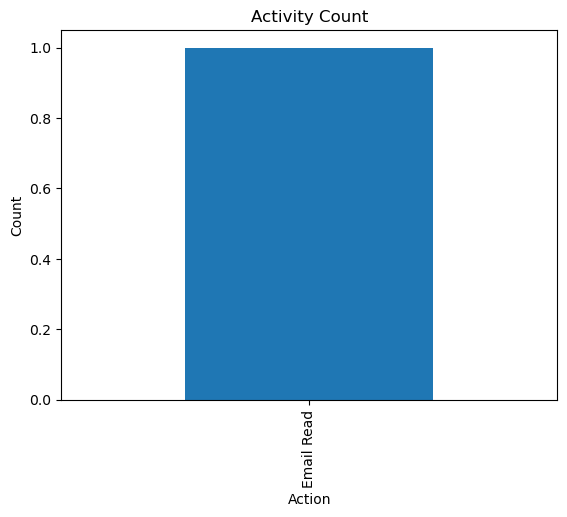

In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -------- LOAD LOGS --------
try:
    with open("logs.json", "r") as f:
        logs = json.load(f)
except:
    logs = []

# -------- CONVERT TO DATAFRAME --------
df = pd.DataFrame(logs)

print("📊 ===== ADMIN DASHBOARD =====")

# -------- TOTAL ACTIVITIES --------
print("\nTotal Activities:", len(df))

if not df.empty:
    # -------- SUMMARY --------
    print("\n📌 Activity Summary:")
    summary = df['action'].value_counts()
    print(summary)

    # -------- TABLE --------
    print("\n📋 Activity Logs:")
    display(df)

    # -------- GRAPH --------
    print("\n📈 Activity Graph:")
    summary.plot(kind='bar')
    plt.title("Activity Count")
    plt.xlabel("Action")
    plt.ylabel("Count")
    plt.show()

else:
    print("\n⚠️ No logs found. Perform actions in assistant first.")